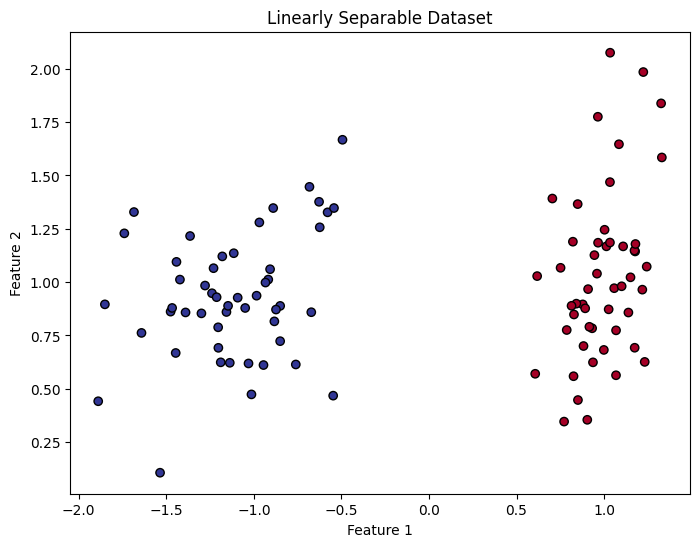

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate a linearly separable dataset
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                           n_informative=2, random_state=1, n_clusters_per_class=1)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Linearly Separable Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [8]:
from meonglentera import FFNN, Layer

print(type(X))

lr = 0.05
model = FFNN([
    Layer(1, 3, activation='relu'),
    Layer(3, 1, activation='sigmoid'),
])
n_epoch = 1000

print([neuron for layer in model.layers for neuron in layer.neurons])

for k in range(n_epoch):
    # Forward pass
    y_pred = [model(x) for x in X]
    loss = sum((yout - yt) ** 2 for yt, yout in zip(y, y_pred))

    # Calculate accuracy
    y_pred_labels = [1 if yout.data > 0.5 else 0 for yout in y_pred]
    accuracy = sum(yt == y_pred_label for yt, y_pred_label in zip(y, y_pred_labels)) / len(y)

    # Backward pass
    model.zero_grad()
    loss.backward_propagate()

    for p in model.parameters():
        p.data += -lr * 0.05 * p.grad

    print(f"Epoch {k + 1}, Loss: {loss.data}, Accuracy: {accuracy * 100:.2f}%")


<class 'numpy.ndarray'>
[Neuron(1, activation=relu), Neuron(1, activation=relu), Neuron(1, activation=relu), Neuron(3, activation=sigmoid)]
Epoch 1, Loss: 21.676182218397294, Accuracy: 50.00%
Epoch 2, Loss: 20.731206447977183, Accuracy: 50.00%
Epoch 3, Loss: 19.858589232541465, Accuracy: 50.00%
Epoch 4, Loss: 19.04883271650269, Accuracy: 50.00%
Epoch 5, Loss: 18.29517692835287, Accuracy: 75.00%
Epoch 6, Loss: 17.5938363033268, Accuracy: 100.00%
Epoch 7, Loss: 16.93414585177527, Accuracy: 100.00%
Epoch 8, Loss: 16.3112268634038, Accuracy: 100.00%
Epoch 9, Loss: 15.72131814476175, Accuracy: 100.00%
Epoch 10, Loss: 15.161052559758055, Accuracy: 100.00%
Epoch 11, Loss: 14.626686594372002, Accuracy: 100.00%
Epoch 12, Loss: 14.115632795222918, Accuracy: 100.00%
Epoch 13, Loss: 13.625677385386425, Accuracy: 100.00%
Epoch 14, Loss: 13.154926942253658, Accuracy: 100.00%
Epoch 15, Loss: 12.701763276344346, Accuracy: 100.00%
Epoch 16, Loss: 12.264805081596924, Accuracy: 100.00%
Epoch 17, Loss: 11